## The CartPole-v1 environment

**CartPole** is a standard benchmark for control and reinforcement learning: a **pole** is hinged on a **cart** that slides along a horizontal track. The agent chooses whether to push the cart left or right so that the pole stays roughly upright and the cart does not drift off the track.

In **Gymnasium’s `CartPole-v1`**, time is discrete. Each timestep the pole and cart evolve under simple dynamics; the agent observes a small state vector and applies one of two forces.

**Rewards:** +1 for every timestep the episode continues (pole still “up” and cart on the track). The episode **terminates** if the pole angle or cart position leaves allowed bounds, or **truncates** after **500** steps.

### Observation (state)

The observation is a **4-dimensional** real vector:

| Index | Quantity | Meaning |
|:---:|---|---|
| 0 | Cart position | Horizontal position of the cart on the track |
| 1 | Cart velocity | Rate of change of cart position |
| 2 | Pole angle | Angle of the pole from vertical (radians; 0 = upright) |
| 3 | Pole angular velocity | Rate of change of pole angle |

*(Numerical ranges follow Gymnasium’s `CartPole-v1` specification; all components are continuous.)*

### Actions

Two **discrete** actions:

| Action value | Effect |
|:---:|:---|
| `0` | Apply force to push the cart **to the left** |
| `1` | Apply force to push the cart **to the right** |

![Schematic of cart on a track with an inverted pendulum](cartpole_diagram.png)



# Vanilla REINFORCE on CartPole-v1

**REINFORCE** (Williams, 1992): Monte Carlo policy gradients with full-episode rollouts. Parameterize a stochastic policy $\pi_\theta(a \mid s)$ and increase probability of actions proportional to their tail returns:

$$
\hat{\nabla}_\theta J \propto \sum_{t=0}^{T-1} G_t \, \nabla_\theta \log \pi_\theta(a_t \mid s_t), \qquad
G_t = \sum_{k=t}^{T-1} \gamma^{k-t} r_k .
$$

This notebook is **only vanilla REINFORCE** (one neural network, weights $G_t$). For REINFORCE **with a learned baseline / advantage** and a variance comparison, see **`reinforce_cartpole_comparison.ipynb`**.

Uses **Gymnasium** (maintained OpenAI Gym API) and **PyTorch**.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 2. Hyperparameters

In [2]:
ENV_ID = "CartPole-v1"
GAMMA = 0.99
LR = 1e-2
HIDDEN = 128
NUM_EPISODES = 2000
PRINT_EVERY = 100

## 3. Policy network

Observation dim 4, two discrete actions. Output **logits** → sample actions from `Categorical(logits)`.

In [3]:
class Policy(nn.Module):
    def __init__(self, obs_dim: int, n_actions: int, hidden: int = HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

## 4. One episode → policy gradient step

After a full trajectory, compute $G_t$ for each $t$, then **policy loss** $-\sum_t \log\pi_\theta(a_t|s_t)\, G_t$.

In [4]:
def discounted_returns(rewards: list[float], gamma: float) -> torch.Tensor:
    """Monte Carlo returns G_t."""
    G = 0.0
    out: list[float] = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return torch.tensor(out, dtype=torch.float32, device=device)


def run_episode(
    env: gym.Env,
    policy: Policy,
    optimizer: optim.Optimizer,
    gamma: float,
    train: bool = True,
) -> float:
    log_probs: list[torch.Tensor] = []
    rewards: list[float] = []
    obs, _ = env.reset()
    done = False
    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        obs, reward, terminated, truncated, _ = env.step(action.item())
        rewards.append(float(reward))
        done = terminated or truncated

    episode_return = float(sum(rewards))
    if train and log_probs:
        G = discounted_returns(rewards, gamma)
        loss = -(torch.stack(log_probs) * G).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return episode_return

## 5. Training and learning curve

Episode     1 | return   14.0 | mean(last 1):   14.0
Episode   100 | return   43.0 | mean(last 100):   45.5
Episode   200 | return   28.0 | mean(last 100):   33.0
Episode   300 | return   56.0 | mean(last 100):   53.8
Episode   400 | return   25.0 | mean(last 100):   47.4
Episode   500 | return   47.0 | mean(last 100):   57.6
Episode   600 | return   38.0 | mean(last 100):   47.9
Episode   700 | return   37.0 | mean(last 100):   51.6
Episode   800 | return   38.0 | mean(last 100):   48.8
Episode   900 | return   32.0 | mean(last 100):   52.5
Episode  1000 | return   61.0 | mean(last 100):   47.7
Episode  1100 | return   55.0 | mean(last 100):   57.6
Episode  1200 | return   43.0 | mean(last 100):   59.1
Episode  1300 | return   31.0 | mean(last 100):   51.8
Episode  1400 | return   30.0 | mean(last 100):   53.2
Episode  1500 | return   39.0 | mean(last 100):   50.6
Episode  1600 | return   58.0 | mean(last 100):   61.3
Episode  1700 | return   57.0 | mean(last 100):   70.3
Episode  180

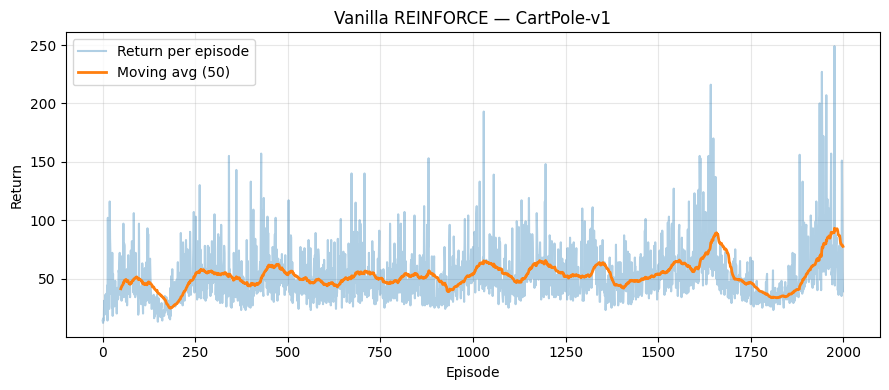

In [5]:
train_env = gym.make(ENV_ID)
obs_dim = train_env.observation_space.shape[0]
n_actions = train_env.action_space.n

policy = Policy(obs_dim, n_actions).to(device)
optimizer = optim.Adam(policy.parameters(), lr=LR)

episode_returns: list[float] = []

for ep in range(1, NUM_EPISODES + 1):
    ret = run_episode(train_env, policy, optimizer, GAMMA, train=True)
    episode_returns.append(ret)
    if ep == 1 or ep % PRINT_EVERY == 0:
        window = episode_returns[-PRINT_EVERY:]
        print(f"Episode {ep:5d} | return {ret:6.1f} | mean(last {len(window)}): {np.mean(window):6.1f}")

train_env.close()

smooth = np.ones(50) / 50
plt.figure(figsize=(9, 4))
plt.plot(episode_returns, alpha=0.35, label="Return per episode")
plt.plot(range(49, len(episode_returns)), np.convolve(episode_returns, smooth, mode="valid"), color="C1", lw=2, label="Moving avg (50)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Vanilla REINFORCE — CartPole-v1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Greedy policy video (`rgb_array`)

In [7]:
def record_policy_video(
    policy: Policy,
    env_id: str,
    max_steps: int = 500,
    seed: int = 123,
) -> list[np.ndarray]:
    env = gym.make(env_id, render_mode="rgb_array")
    frames: list[np.ndarray] = []
    obs, _ = env.reset(seed=seed)
    done = False
    steps = 0
    policy.eval()
    with torch.no_grad():
        while not done and steps < max_steps:
            frames.append(env.render())
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            logits = policy(obs_t)
            action = int(torch.argmax(logits, dim=1).item())
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1
    env.close()
    policy.train()
    return frames


def animate_frames(frames: list[np.ndarray], interval_ms: int = 40) -> HTML:
    fig = plt.figure(figsize=(8, 5))
    ax = plt.axes([0, 0, 1, 1], frameon=False)
    ax.axis("off")
    im = ax.imshow(frames[0])

    def update(i: int):
        im.set_data(frames[i])
        return (im,)

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())


video_frames = record_policy_video(policy, ENV_ID)
print(f"Greedy rollout: {len(video_frames)} steps.")
display(animate_frames(video_frames))

Greedy rollout: 43 steps.


**Next:** open **`reinforce_cartpole_comparison.ipynb`** for REINFORCE with a learned baseline $V_\phi(s)$, advantages $A_t = G_t - V_\phi(s_t)$, and variance plots vs this vanilla setup.

CartPole-v1 truncates after 500 steps; raise `NUM_EPISODES` or tune `LR` if learning is unstable.